Importing Dataset


In [2]:
# import requirement libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import itertools

# for solve problem of show plotly plots
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

# optional
import warnings
warnings.filterwarnings('ignore')
plt.style.use('_mpl-gallery')

In [3]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

In [4]:
# import dataset
data = pd.read_csv('Customer_Behaviour.csv')
print(f"shape: {data.shape}")
data.head()

shape: (400, 5)


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


Overview of Dataset

In [5]:
df = pd.DataFrame(data)
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


According to the above information:
 - It seems that there are no missing values, which will be checked in more detail below.
 - We have 4 features including `User ID`, `Gender`, `Age` and `EstimatedSalary`.
 - Our target is `Purchased`
 - We have only one categorical data that is `Gender`

Preparing Dataset


In [7]:
# Check missing value
df.isnull().sum().to_frame('NaN value').T

,User ID,Gender,Age,EstimatedSalary,Purchased
NaN value,0,0,0,0,0


check each columns for detect syntax error or invalid values

In [8]:
# check count of unique values in each columns
for col in df:
    print(f"{col}: {df[col].nunique()}")

User ID: 400
Gender: 2
Age: 43
EstimatedSalary: 117
Purchased: 2


In [9]:
# more details
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
User ID,400.0,1.569154e+07,71658.321581,15566689.0,15626763.75,15694341.5,15750363.0,15815236.0
Age,400.0,3.765500e+01,10.482877,18.0,29.75,37.0,46.0,60.0
EstimatedSalary,400.0,6.974250e+04,34096.960282,15000.0,43000.00,70000.0,88000.0,150000.0
Purchased,400.0,3.575000e-01,0.479864,0.0,0.00,0.0,1.0,1.0


In [10]:
df.describe(include=[object]).T

,count,unique,top,freq
Gender,400,2,Female,204


According to above tables:
 - The age range is between 16 and 60 years.
 - Target includes 2 classes 1 and 0.
 - The number of male and female in the dataset is almost the same.
 - The range of features are very different from each other and there is a need for standardization.

We do not need the user ID column to build the predictive model, so we drop it

In [11]:
# Drop User ID columns
df.drop('User ID', axis=1, inplace=True)
df

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0
...,...,...,...,...
395,Female,46,41000,1
396,Male,51,23000,1
397,Female,50,20000,1
398,Male,36,33000,0


In [12]:
# convert categoriacl feature to numerical:
# only Gender is categorical
df['Gender'] = df['Gender'].replace(['Male', 'Female'], [0, 1])
df

,Gender,Age,EstimatedSalary,Purchased
0,0,19,19000,0
1,0,35,20000,0
2,1,26,43000,0
3,1,27,57000,0
4,0,19,76000,0
...,...,...,...,...
395,1,46,41000,1
396,0,51,23000,1
397,1,50,20000,1
398,0,36,33000,0


Now check dataset for the last time

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Gender           400 non-null    int64
 1   Age              400 non-null    int64
 2   EstimatedSalary  400 non-null    int64
 3   Purchased        400 non-null    int64
dtypes: int64(4)
memory usage: 12.6 KB


In [14]:
df.isna().sum()

Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Alright, let's continue

Exploratory Data Analysis (EDA)


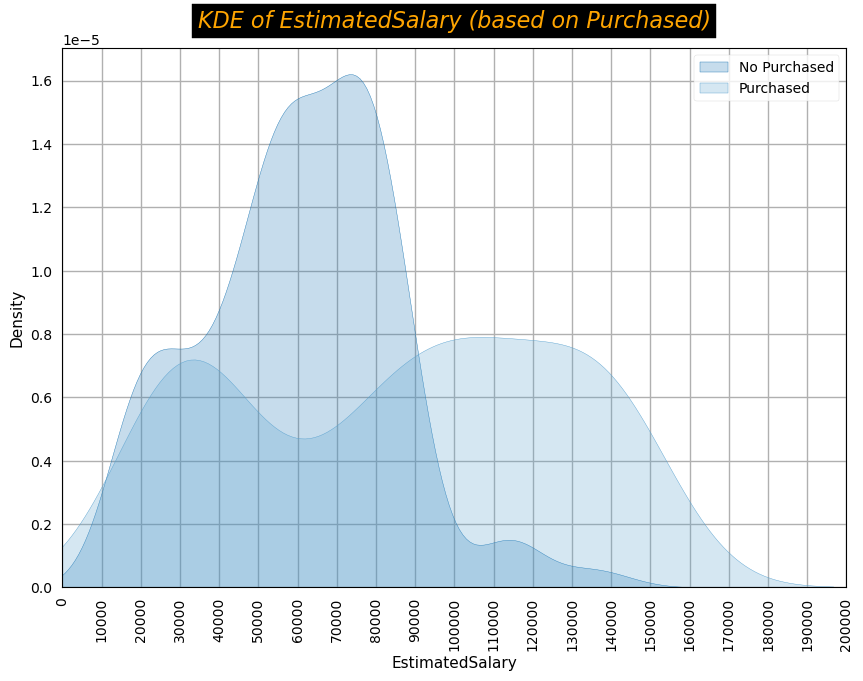

In [15]:
# check distribution of EstimatedSalary (based on Purchased)
font = {'fontsize':16, 'fontstyle':'italic', 'backgroundcolor':'black', 'color':'orange'}
%matplotlib inline
plt.style.use('seaborn-v0_8-notebook')
sns.kdeplot(df.loc[df['Purchased'] == 0, 'EstimatedSalary'], label='No Purchased', shade=True)
sns.kdeplot(df.loc[df['Purchased'] == 1, 'EstimatedSalary'], label='Purchased', shade=True)
plt.title('KDE of EstimatedSalary (based on Purchased)', fontdict=font, pad=15)
plt.xticks(np.arange(0,200001,10000), rotation=90)
plt.xlim([0,200001])
plt.legend()
plt.show()



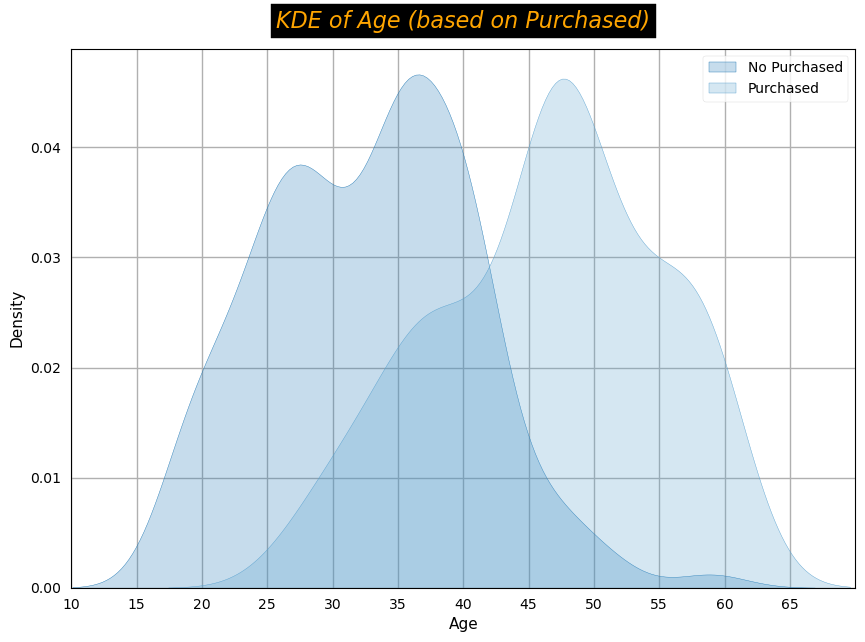

In [16]:
# check distribution of Purchased (based on Purchased)
%matplotlib inline
plt.style.use('seaborn-v0_8-notebook')
sns.kdeplot(df.loc[df['Purchased'] == 0, 'Age'], label='No Purchased', shade=True)
sns.kdeplot(df.loc[df['Purchased'] == 1, 'Age'], label='Purchased', shade=True)
plt.title('KDE of Age (based on Purchased)', fontdict=font, pad=15)
plt.xticks(np.arange(0,70,5))
plt.xlim([10,70])
plt.legend()
plt.show()

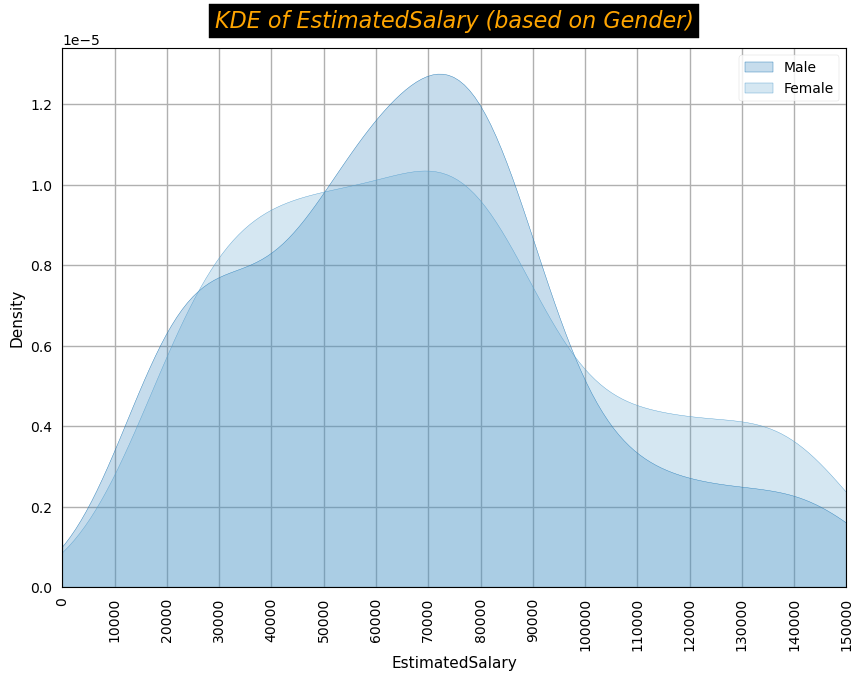

In [17]:
# check distribution of EstimatedSalary (based on Gender)
%matplotlib inline
plt.style.use('seaborn-v0_8-notebook')
sns.kdeplot(df.loc[df['Gender'] == 0, 'EstimatedSalary'], label='Male', shade=True)
sns.kdeplot(df.loc[df['Gender'] == 1, 'EstimatedSalary'], label='Female', shade=True)
plt.title('KDE of EstimatedSalary (based on Gender)', fontdict=font, pad=15)
plt.xticks(np.arange(0,150001,10000), rotation=90)
plt.xlim([0,150001])
plt.legend()
plt.show()

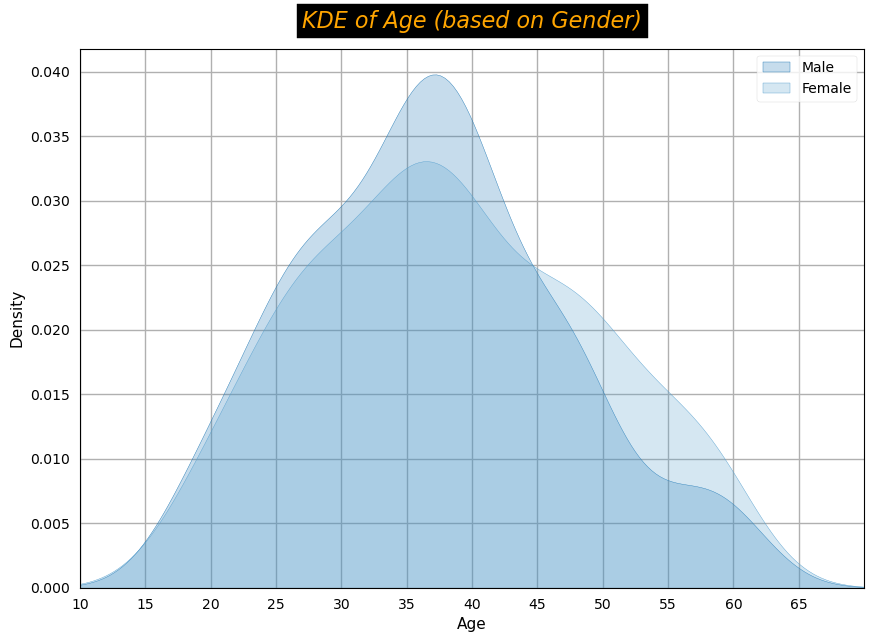

In [18]:
# check distribution of Age (based on Gender)
%matplotlib inline
plt.style.use('seaborn-v0_8-notebook')
sns.kdeplot(df.loc[df['Gender'] == 0, 'Age'], label='Male', shade=True)
sns.kdeplot(df.loc[df['Gender'] == 1, 'Age'], label='Female', shade=True)
plt.title('KDE of Age (based on Gender)', fontdict=font, pad=15)
plt.xticks(np.arange(0,70,5))
plt.xlim([10,70])
plt.legend()
plt.show()

According to above kde plots:
 - Most people whose income is between 40000 and 90000 don't decide to purchase a product.
 - Most people whose income is between 40000 and 90000 don't decide to purchase a product.
 - Most people who decide to purchase a product are older than people who don't decide to purchase a product.
 - People over the age of 43 are often interested in purchase a product.
 - Based on Gender for each male or female, kde is almost same.

Univariate Analysis


In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Gender,400.0,0.5100,0.500526,0.0,0.00,1.0,1.0,1.0
Age,400.0,37.6550,10.482877,18.0,29.75,37.0,46.0,60.0
EstimatedSalary,400.0,69742.5000,34096.960282,15000.0,43000.00,70000.0,88000.0,150000.0
Purchased,400.0,0.3575,0.479864,0.0,0.00,0.0,1.0,1.0


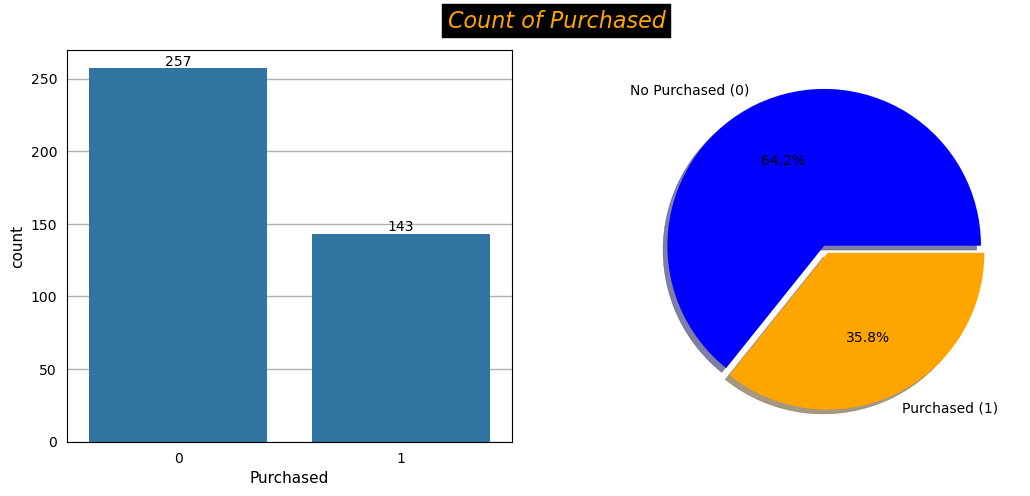

In [20]:
# count based on Purchased (countplot)
fig, axes = plt.subplots(1,2,figsize=(10,4))

sns.countplot(data=df, x='Purchased', ax=axes[0])
for container in axes[0].containers:
    axes[0].bar_label(container)

# count based on Purchased (pie chart)
slices = df.Purchased.value_counts().values
activities = ['No Purchased (0)', 'Purchased (1)']
axes[1].pie(slices, labels=activities, colors=['blue','orange'], shadow=True, explode=[0,0.05], autopct='%1.1f%%')

plt.suptitle('Count of Purchased', y=1.09, **font)
plt.show()

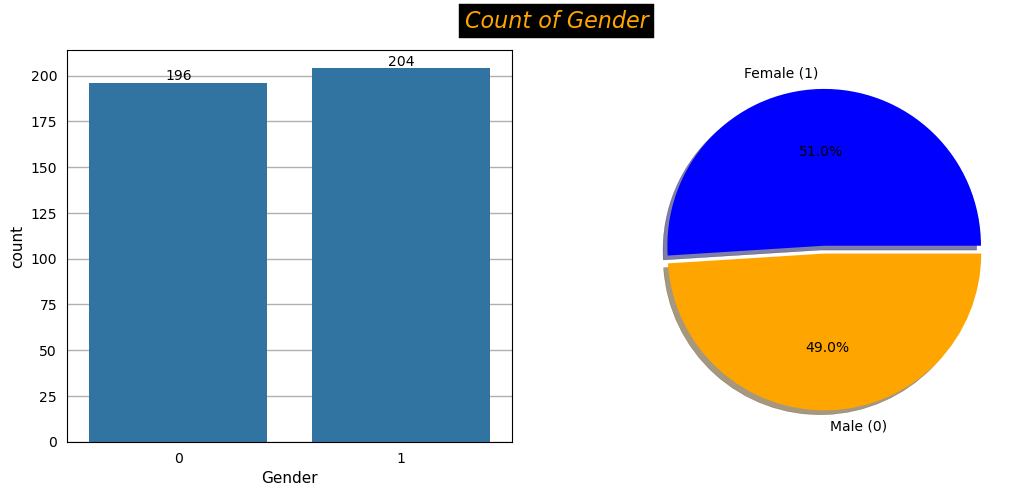

In [21]:
# count based on Gender (countplot)
fig, axes = plt.subplots(1,2,figsize=(10,4))

sns.countplot(data=df, x='Gender', ax=axes[0])
for container in axes[0].containers:
    axes[0].bar_label(container)

# count based on Gender (pie chart)
slices = df.Gender.value_counts().values
activities = ['Female (1)', 'Male (0)']
axes[1].pie(slices, labels=activities, colors=['blue','orange'], shadow=True, explode=[0,0.05], autopct='%1.1f%%')

plt.suptitle('Count of Gender', y=1.09, **font)
plt.show()

According to above barplots and tabel:
 - The number of male and female is almost the same
 - he number of people who decide to purchased a product is less than the number of people who do not decide to purchased a product.

Bivariate Analysis


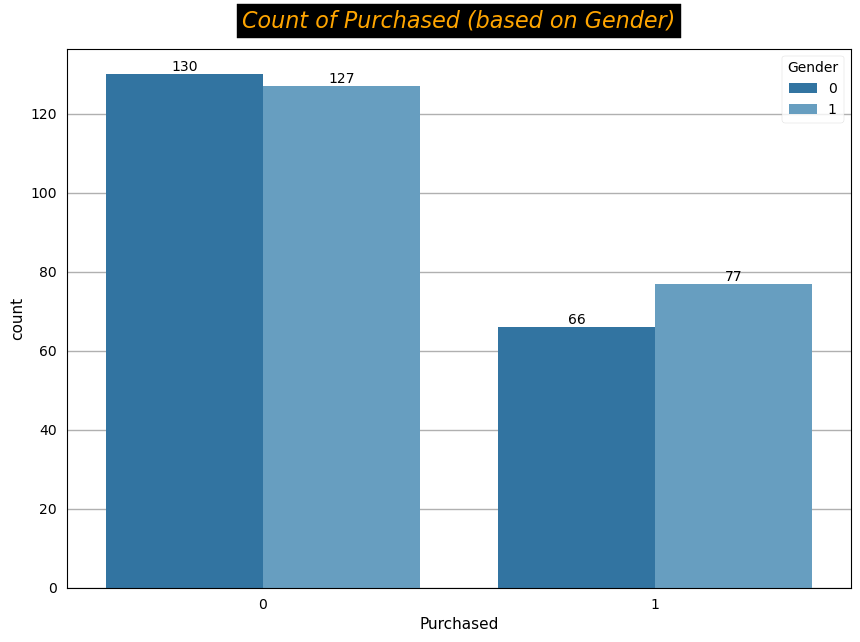

In [22]:
# count of purchased based on Gender
%matplotlib inline
ax = sns.countplot(data=df, x='Purchased', hue='Gender')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Count of Purchased (based on Gender)', fontdict=font, pad=15)
plt.show()

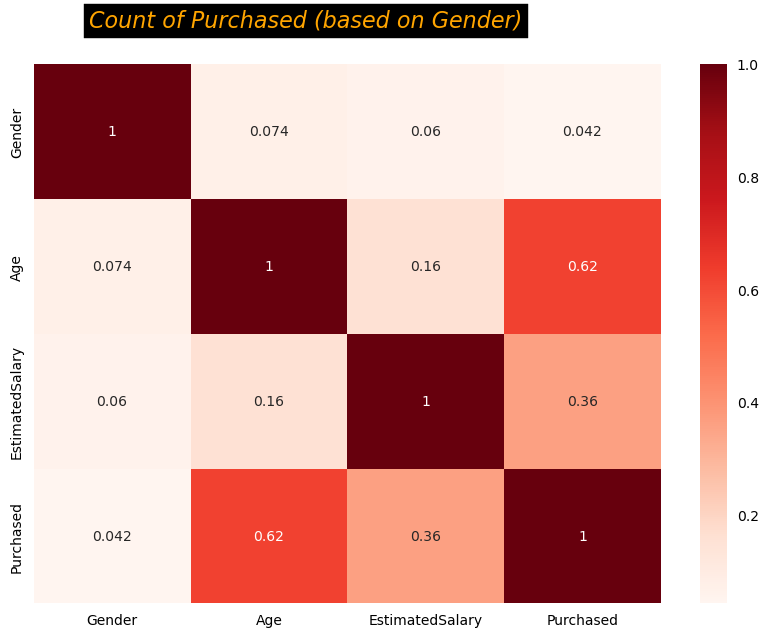

In [23]:
# heatmap
sns.heatmap(df.corr(), cmap='Reds', annot=True)
plt.suptitle('Count of Purchased (based on Gender)', y=1.09, x=0.35, **font)
plt.show()

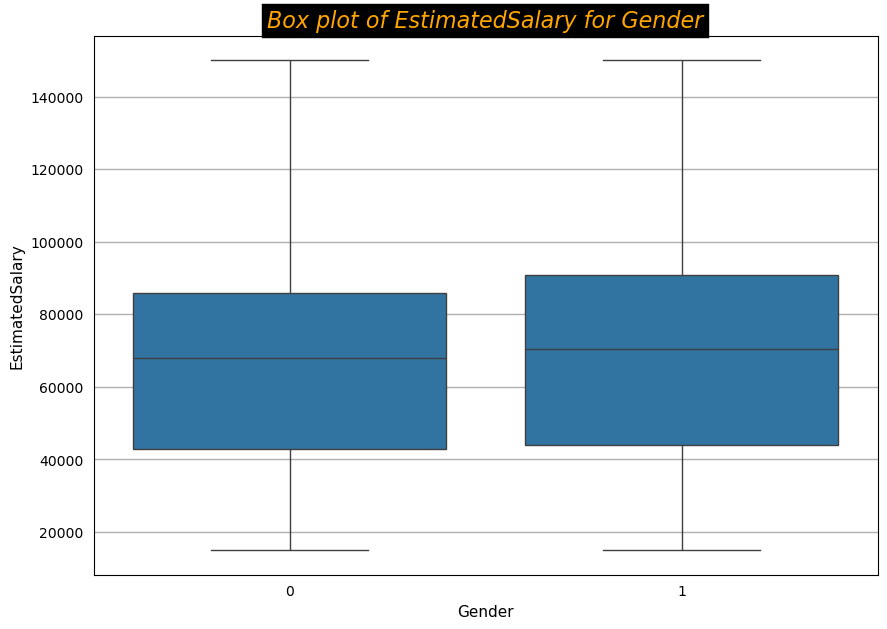

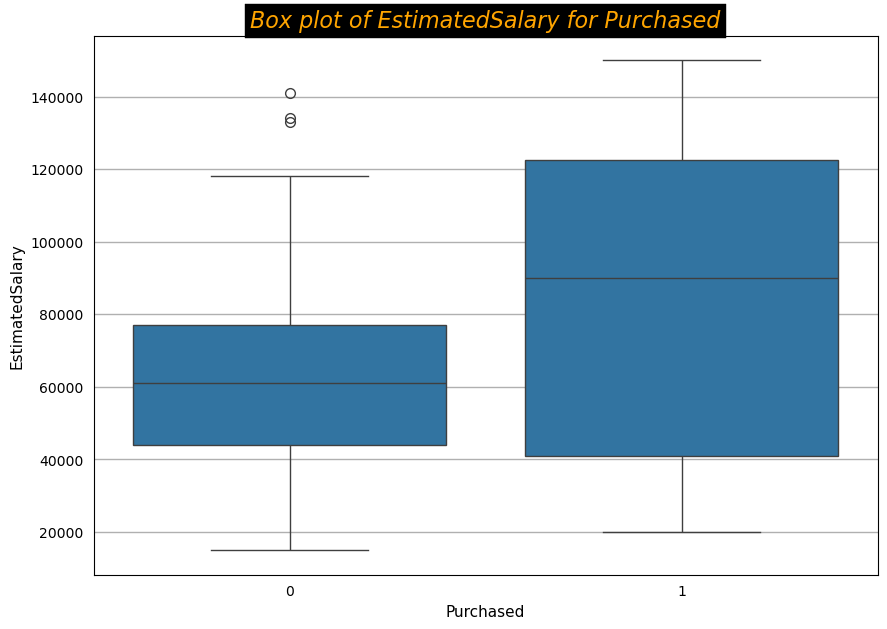

In [24]:
# draw box plot of Estimated salary for male(0) or female(1) Gender
# draw box plot of Estimated salary for no purchased(0) or purchased(1)
for col in ['Gender', 'Purchased']:
    sns.boxplot(data=df, x=col, y='EstimatedSalary')
    plt.title(f'Box plot of EstimatedSalary for {col}', fontdict=font)
    plt.show()

According to above plots:
 - Among the people who decide to purchase a product, there are more female than male, but among the people who do not decide to purchase a product, there are more male.
 - The highest correlation is between Purchased and Age (0.62).
 - The average EstimatedSalary of people who decide to purchase a product is higher than people who do not decide to purchase a product.
 - Average EstimatedSalary of male and female do not differ much.

Multivariate Analysis

We use scatter plots to examine data that is numerical in nature.

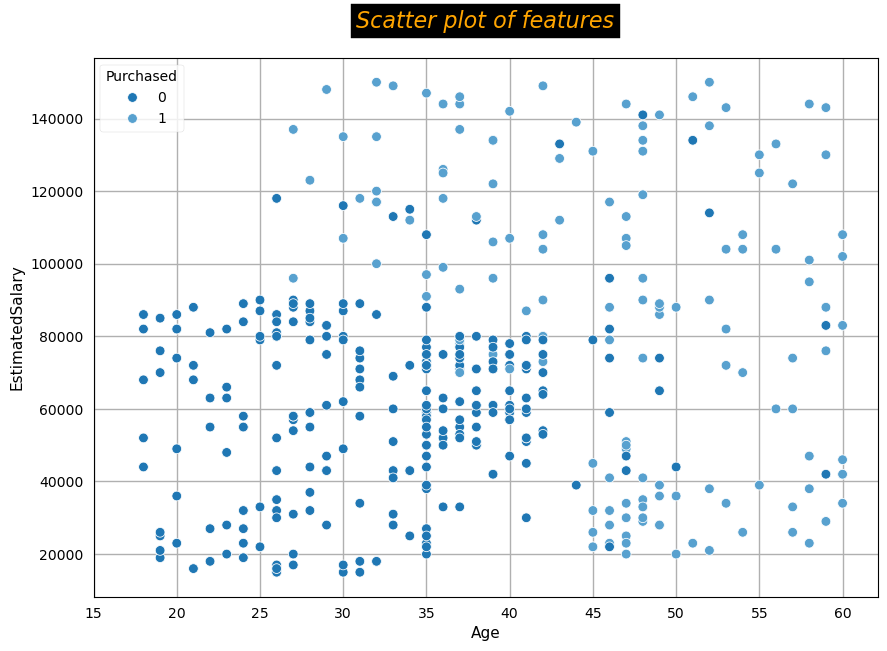

In [25]:
%matplotlib inline
# check feature correlation
sns.scatterplot(data=df,x='Age', y='EstimatedSalary', hue='Purchased',)
plt.title('Scatter plot of features', y=1.04, fontdict=font)
plt.xticks(np.arange(15,65,5))
plt.show()

For a better view, we draw a 3D scatter plot

In [26]:
import plotly.express as px
import plotly.io as pio

# Ensure Gender is numeric
if df['Gender'].dtype == 'object':
    df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Plot
fig = px.scatter_3d(
    data_frame=df,
    x='Age',
    y='EstimatedSalary',
    z='Gender',
    color='Purchased',
    template='ggplot2',
    opacity=0.6,
    height=700,
    title='3D Scatter Plot: Age, Salary, Gender, and Purchased'
)

pio.show(fig)


In [27]:
# check mean of EstimatedSalary based on Gender and Purchased
results = pd.pivot_table(data=df, index='Purchased', columns='Gender', values='EstimatedSalary')
results.style.background_gradient(cmap='summer_r')

Gender,0,1
Purchased,,
0,59630.769231,61480.314961
1,83424.242424,88714.285714


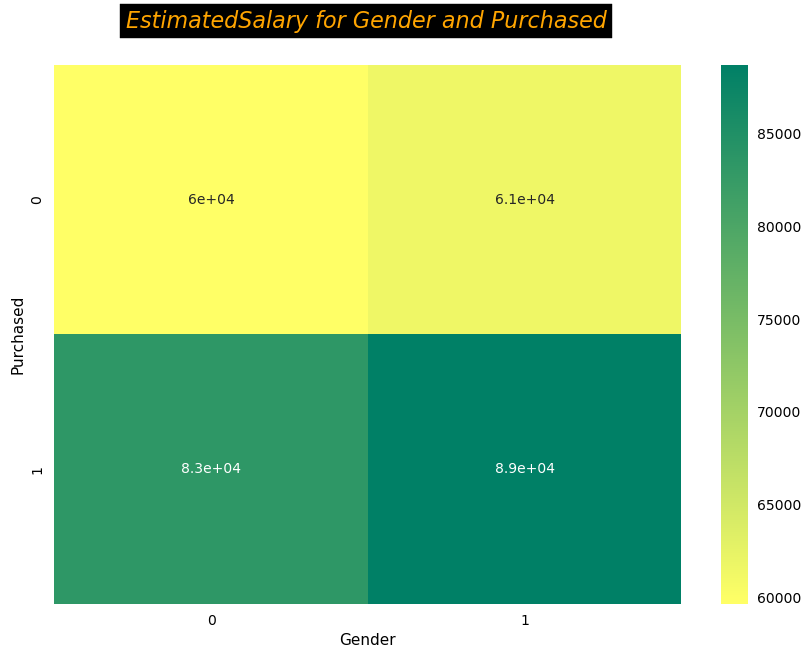

In [28]:
# show result in heatmap
sns.heatmap(results, cmap='summer_r', annot=True)
plt.suptitle('EstimatedSalary for Gender and Purchased', y=1.09, x=0.4, **font)
plt.show()

In [29]:
# check mean of Age based on Gender and Purchased
results = pd.pivot_table(data=df, index='Purchased', columns='Gender', values='Age')
results.style.background_gradient(cmap='summer_r')

Gender,0,1
Purchased,,
0,32.484615,33.110236
1,45.500000,47.155844


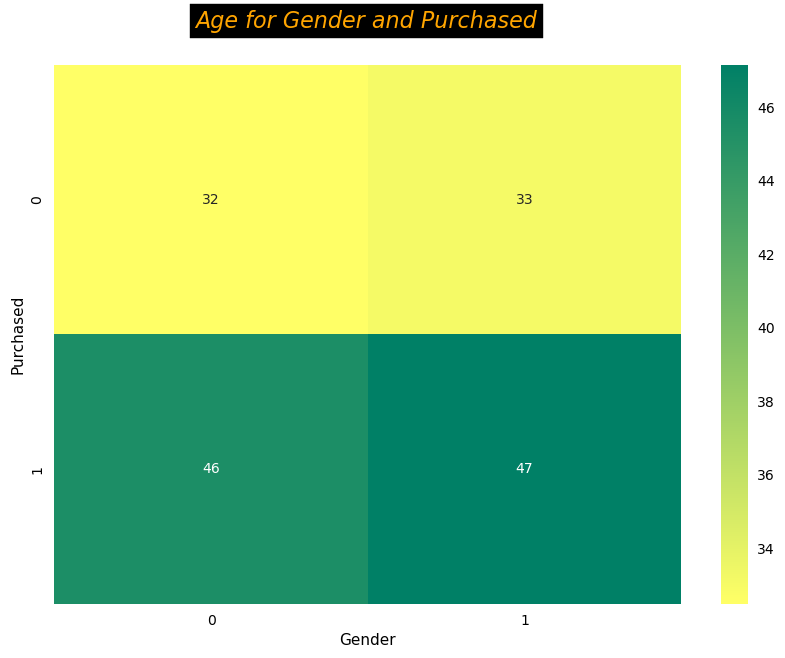

In [30]:
# show result in heatmap
sns.heatmap(results, cmap='summer_r', annot=True)
plt.suptitle('Age for Gender and Purchased', y=1.09, x=0.4, **font)
plt.show()

According to above plots:
- People with young age and low EstimatedSalary often do not have a decision to purchase product.
- People with a EstimatedSalary of more than 100000, regardless of their Age, often decide to purchase product.
- People over the age of 45, regardless of their EstimatedSalary, are more likely to pruchase a product.

These plots also confirm the previous results


Building Models


In [31]:
# Our dataset we use for modeling
df

,Gender,Age,EstimatedSalary,Purchased
0,0,19,19000,0
1,0,35,20000,0
2,1,26,43000,0
3,1,27,57000,0
4,0,19,76000,0
...,...,...,...,...
395,1,46,41000,1
396,0,51,23000,1
397,1,50,20000,1
398,0,36,33000,0


**NAIVE BAYES**

We have b
oth discrete and continuous types of data can be seen in the dataset, so among the types of Naive Bayes, we use the Multinomial Naive Bayes.
Considering that the range of features are very different, as mentioned before, they should be standardized first.

In [32]:
# standardize EstimatedSalary and Age with StandardScaler
df2 = df.copy()
scaler = MinMaxScaler(feature_range=(18,60)).fit(df[['EstimatedSalary']])
df2['EstimatedSalary'] = scaler.transform(df2['EstimatedSalary'].values.reshape(-1,1))
df2

,Gender,Age,EstimatedSalary,Purchased
0,0,19,19.244444,0
1,0,35,19.555556,0
2,1,26,26.711111,0
3,1,27,31.066667,0
4,0,19,36.977778,0
...,...,...,...,...
395,1,46,26.088889,1
396,0,51,20.488889,1
397,1,50,19.555556,1
398,0,36,23.600000,0


In [33]:
# define x (features) and y (target)
x = np.asanyarray(df2.drop('Purchased', axis=1))
y = df2.Purchased.values.reshape(-1,1)

In [34]:
FPR1 = []
TPR1 = []
FPR0 = []
TPR0 = []
ACC_test = []
ACC_train = []
Recall = []
Precision = []
F1 = []

def plot_confusion_matrix2(cm, classes,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function plots the confusion matrix.
        cm(array): confusion matrix
        classes(dictionary): classes in our target
    """
    plt.figure(figsize=(10,7))
    plt.grid(False)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt ='d'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")


    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

# --------------------------------------------------------------------------------------

def Perform_cross_val(model, k, x, y, scoring):
    """
    perform cross validation
        model: logistic model
        k(scaler): the value for n_splits in KFold()
        x(DataFrame or array):  x_train
        y(DataFrame or array): y_train
        scoring(string): an approach for evaluation in cross validation
    """

    kf = KFold(n_splits=k)
    cv_results = cross_val_score(model, x, y, cv=kf, scoring=scoring)
    cv_mean = np.mean(cv_results)
    print('-'*20, f"CV for k={k}, scoring={scoring}", '-'*20)
    print(f"CV mean: {cv_mean}")
    print(f"CV results: {cv_results}\n")

# --------------------------------------------------------------------------------------

def find_fold_index(k, x):
    """
    Find fold index in kfold
        k(scaler): the value used for n_splits in KFold()
        x(DataFrame or array): x_train
    """

    my_fold_index = []
    j=1
    for _ , test in KFold(k).split(x):

        my_fold_index = []
        for i in test:
            my_fold_index.append(i)
        print(f"fold {j}: [{my_fold_index[0]},{my_fold_index[-1]}]")
        print(20*'-')
        j += 1

# --------------------------------------------------------------------------------------

def plot_results(FPR0, TPR0, FPR1, TPR1, ACC_test, ACC_train, Recall, Precision, F1):
    """
    draw ROC curve and plot of Recall, precision, f1 score etc.
        FPR0(list): list of False Positive Rate for class 0
        TPR0(list): list of True Positive Rate for class 0
        FPR1(list): list of Flase Positive Rate for class 1
        TPR1(list): list of True Positive Rate for class 1
        ACC(list): list of accuracy of models
        Recall(list): list of recall score of models
        Precision(list): list of Precision score of models
        F1(list): list of F1 score of models
    """
    fig, ax = plt.subplots(1,2,figsize=(10,4))
    # plot model evaluation
    ax[0].set_title('Model Evaluation Results', fontdict=font, y=1.02)
    sns.lineplot(data=pd.DataFrame({'accoracy': ACC_test, 'Recall': Recall,
                                    'Precision': Precision, 'F1 score': F1}),
                                    markers=True, ax=ax[0])
    ax[0].set_xlabel('M')
    ax[0].set_ylabel('Evaluation')
    ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True)

    # plot model evaluation
    ax[1].set_title('Model Accuracy Results for train and test', fontdict=font, y=1.02)
    sns.lineplot(data=pd.DataFrame({'test accuracy': ACC_test, 'train accuracy': ACC_train}),
                                    markers=True, ax=ax[1])
    ax[1].set_xlabel('M')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True)
    plt.show()

    # plot ROC curve for class 1
    fig, ax = plt.subplots(1,2,figsize=(10,4))
    i=1
    ax[0].set_title('ROC Curve of Class 1', fontdict=font, y=1.02)
    for fpr , tpr in zip(FPR1, TPR1):
        ax[0].plot(fpr, tpr, label=f"ROC curve of model{i} (AUC = {round(metrics.auc(fpr, tpr),3)})")
        i += 1
        ax[0].set_xlabel('FPR')
        ax[0].set_ylabel('TPR')
    ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          fancybox=True, shadow=True)

    # plot ROC curve for class zero
    i=1
    ax[1].set_title('ROC Curve of Class 0', fontdict=font, y=1.02)
    for fpr , tpr in zip(FPR0, TPR0):
        ax[1].plot(fpr, tpr, '--', label=f"ROC curve of model{i} (AUC = {round(metrics.auc(fpr, tpr),3)})")
        i += 1
        ax[1].set_xlabel('FPR')
        ax[1].set_ylabel('TPR')
    ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
        fancybox=True, shadow=True)

    plt.show()

# --------------------------------------------------------------------------------------

def modeling(x, y, test_size, classes, is_add=1 ):

    # split data to train and test
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=0)
    print(20*'-', 'Shape', 20*'-')
    print(f"x_train: {x_train.shape}")
    print(f"y_train: {y_train.shape}")
    print(f"x_test: {x_test.shape}")
    print(f"y_test: {y_test.shape}")



    # define model and fit model
    clf = MultinomialNB()
    clf.fit(x_train, y_train.ravel())

    # prediction and results
    y_pred_train = clf.predict(x_train)
    y_pred_test = clf.predict(x_test)
    y_proba_train = clf.predict_proba(x_train)
    y_proba_test = clf.predict_proba(x_test)

    cm = metrics.confusion_matrix(y_test, y_pred_test)
    fpr1, tpr1, _ = metrics.roc_curve(y_test, y_proba_test[:,1])
    fpr0, tpr0, _ = metrics.roc_curve(y_test, y_proba_test[:,0])
    acc_test = metrics.accuracy_score(y_test, y_pred_test)
    acc_train = metrics.accuracy_score(y_train, y_pred_train)
    rec = metrics.recall_score(y_test, y_pred_test)
    pre = metrics.precision_score(y_test, y_pred_test)
    f1 = metrics.f1_score(y_test, y_pred_test)

    # append results
    if is_add == 1:
        FPR0.append(fpr0)
        TPR0.append(tpr0)
        FPR1.append(fpr1)
        TPR1.append(tpr1)
        ACC_test.append(acc_test)
        ACC_train.append(acc_train)
        Recall.append(rec)
        Precision.append(pre)
        F1.append(f1)

    plot_results(FPR0, TPR0, FPR1, TPR1, ACC_test, ACC_train, Recall, Precision, F1)

    # Evaluation model
    print('-'*20 , 'Confusion Matrix', '-'*20)
    print(cm)
    plot_confusion_matrix2(cm, classes,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues)
    # or use plot_confusion_matrix from sklearn.metrics
    print('-'*20 , 'Classification Report', '-'*20)
    print(metrics.classification_report(y_test, y_pred_test, target_names=classes), '\n')
    print(f"Jaccard Score: {metrics.jaccard_score(y_test, y_pred_test)}", '\n')

    # print other result about predicted data
    return clf, acc_test, acc_train

-------------------- Shape --------------------
x_train: (320, 3)
y_train: (320, 1)
x_test: (80, 3)
y_test: (80, 1)


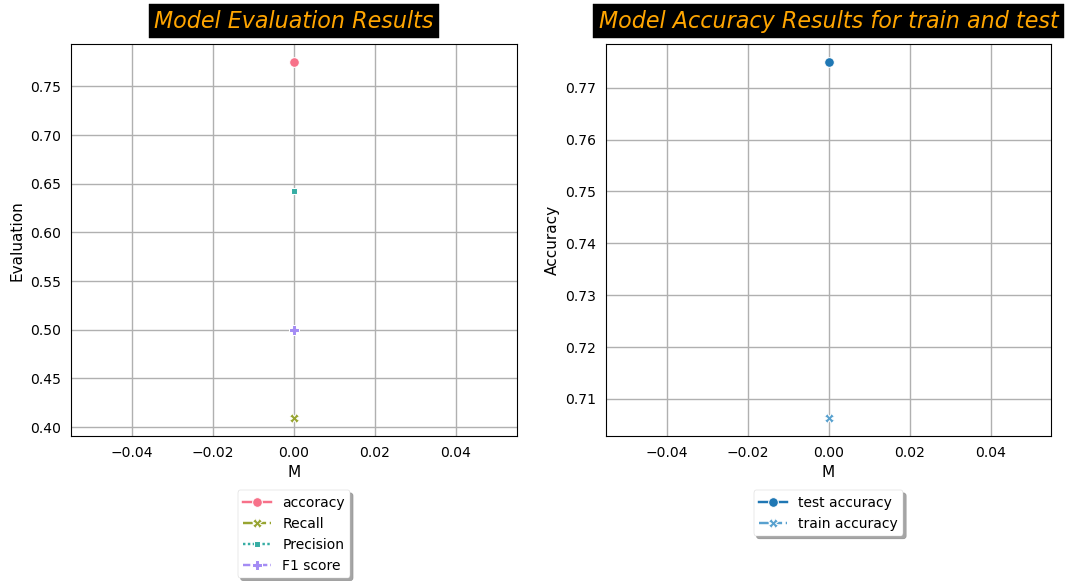

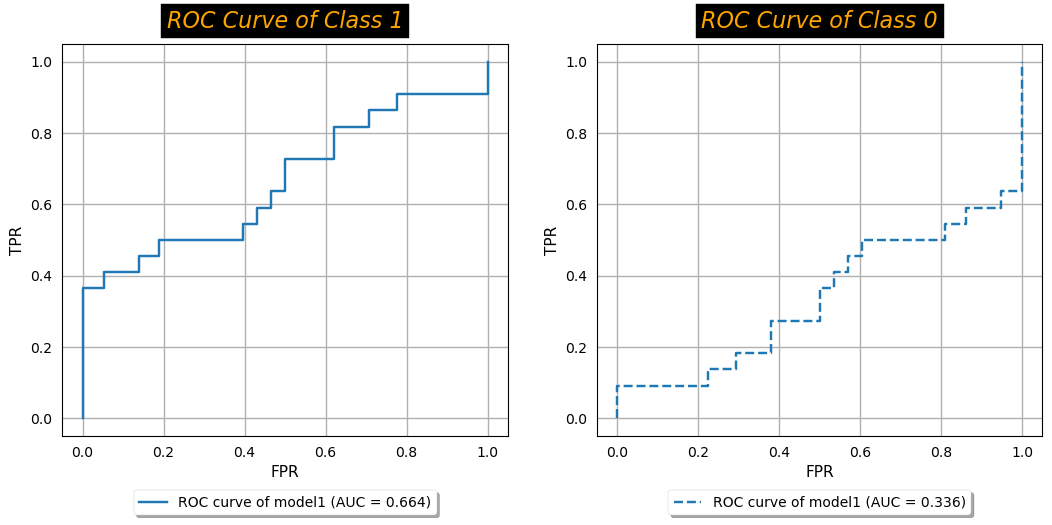

-------------------- Confusion Matrix --------------------
[[53  5]
 [13  9]]


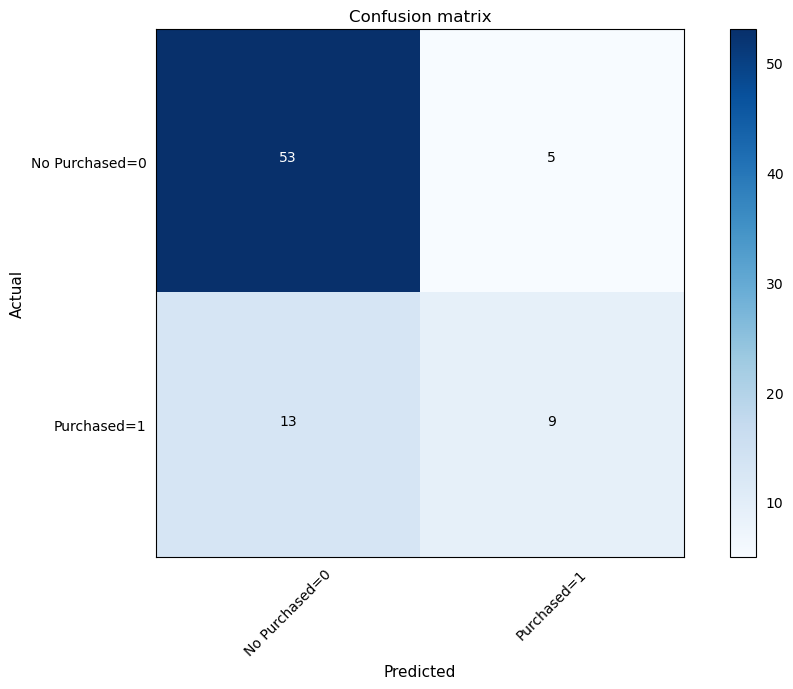

-------------------- Classification Report --------------------
                precision    recall  f1-score   support

No Purchased=0       0.80      0.91      0.85        58
   Purchased=1       0.64      0.41      0.50        22

      accuracy                           0.78        80
     macro avg       0.72      0.66      0.68        80
  weighted avg       0.76      0.78      0.76        80
 

Jaccard Score: 0.3333333333333333 



In [35]:
# Now create first model
clf1, acc_test1, acc_train1 = modeling(x, y, 0.2, ['No Purchased=0', 'Purchased=1'])

Accuracy is 0.78 and that is not bad but we want to improve model, so let's countinue.

<div style="color:orange;
           display:fill;
           border-radius:5px;
           font-family:Verdana;
           letter-spacing:0.5px;
           background-color:black;
            text-align:center;
            padding: 1px;">

<h1 id="head6">
    <p style="padding: 6px;
              font-size:100%;
              color:orange;
              text-align:center;">
              5. Improve Model
    <a class="anchor-link" href="https://www.kaggle.com/arezalo/customer-behaviour-prediction-naive-bayes#head6">¶</a></p>
</h1>
</div>

First test some test_size for improve model

-------------------- Shape --------------------
x_train: (280, 3)
y_train: (280, 1)
x_test: (120, 3)
y_test: (120, 1)


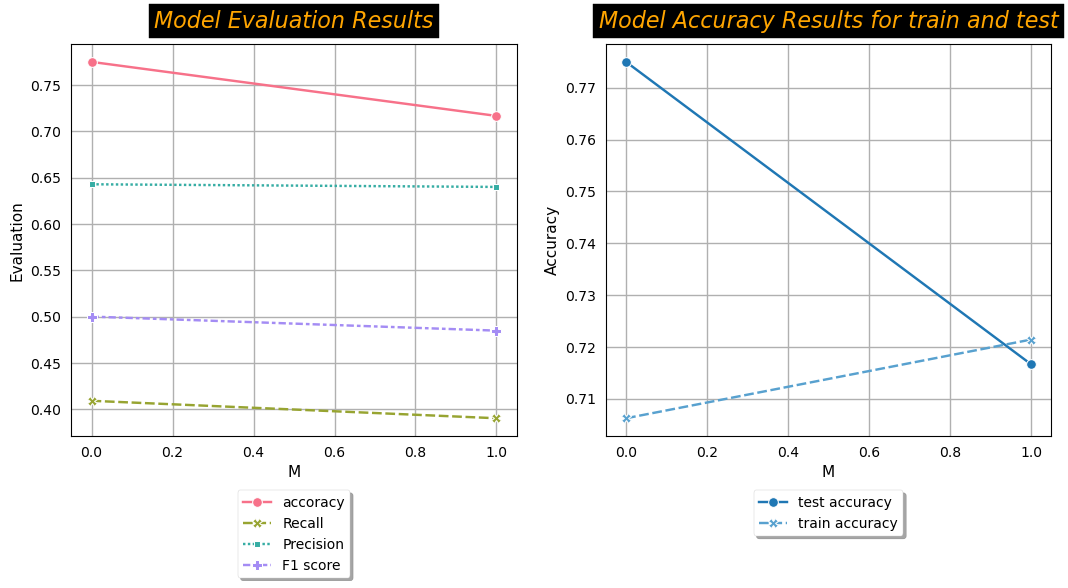

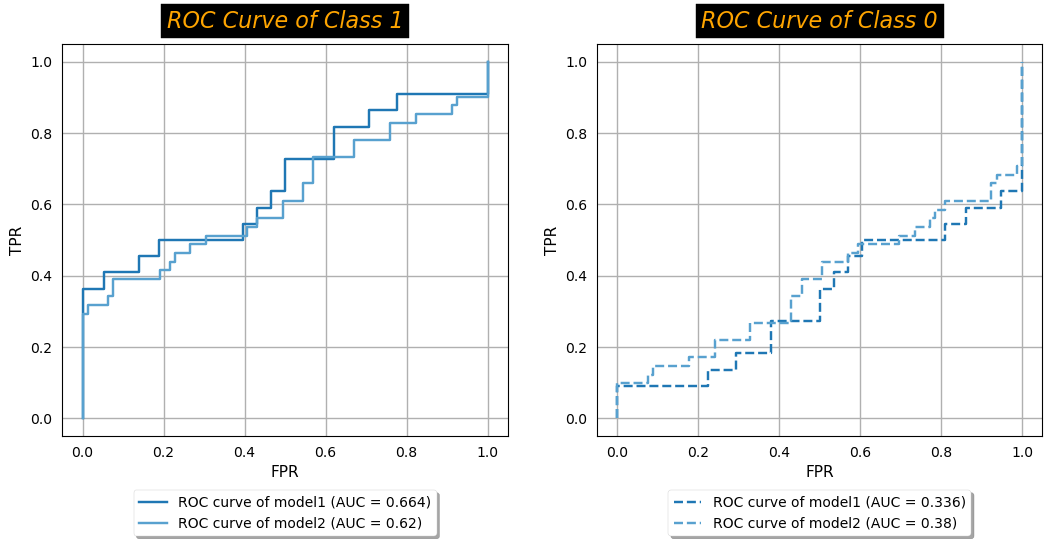

-------------------- Confusion Matrix --------------------
[[70  9]
 [25 16]]


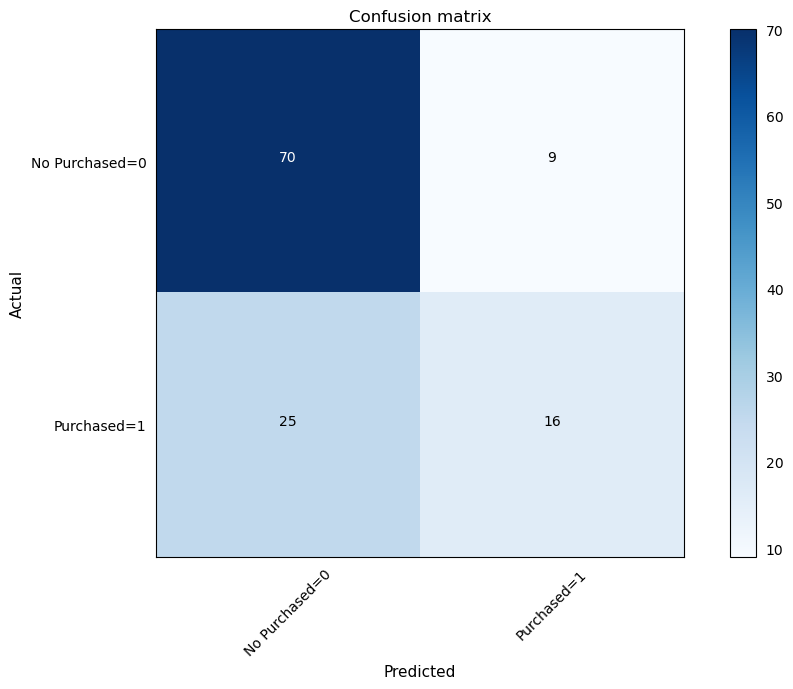

-------------------- Classification Report --------------------
                precision    recall  f1-score   support

No Purchased=0       0.74      0.89      0.80        79
   Purchased=1       0.64      0.39      0.48        41

      accuracy                           0.72       120
     macro avg       0.69      0.64      0.64       120
  weighted avg       0.70      0.72      0.70       120
 

Jaccard Score: 0.32 



In [36]:
# test test_size= 0.3
clf2, acc_test2, acc_train2 = modeling(x, y, 0.3, ['No Purchased=0', 'Purchased=1'])

test_size = 0.3 did not improve the performance of the model.

-------------------- Shape --------------------
x_train: (340, 3)
y_train: (340, 1)
x_test: (60, 3)
y_test: (60, 1)


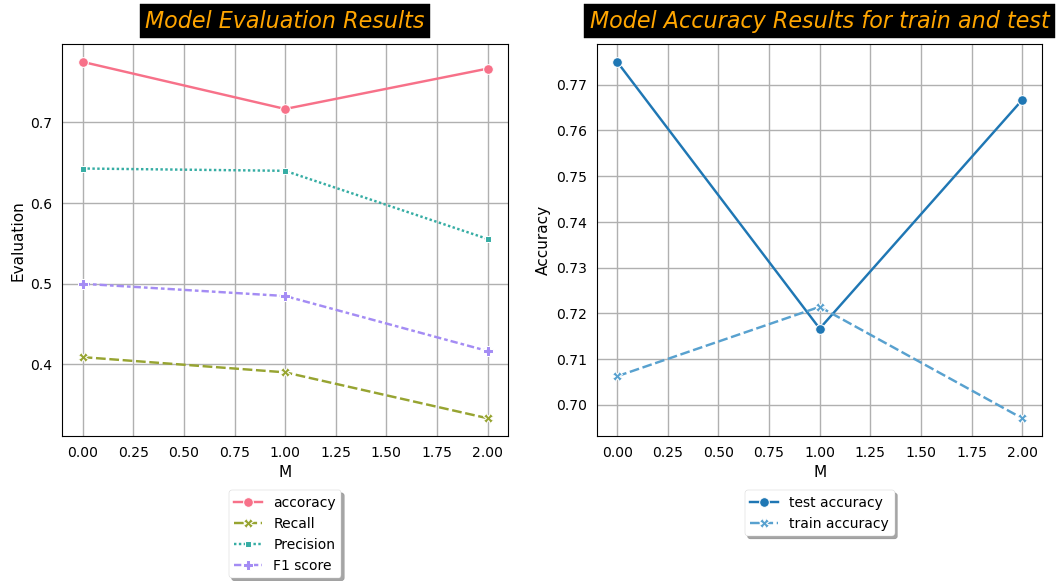

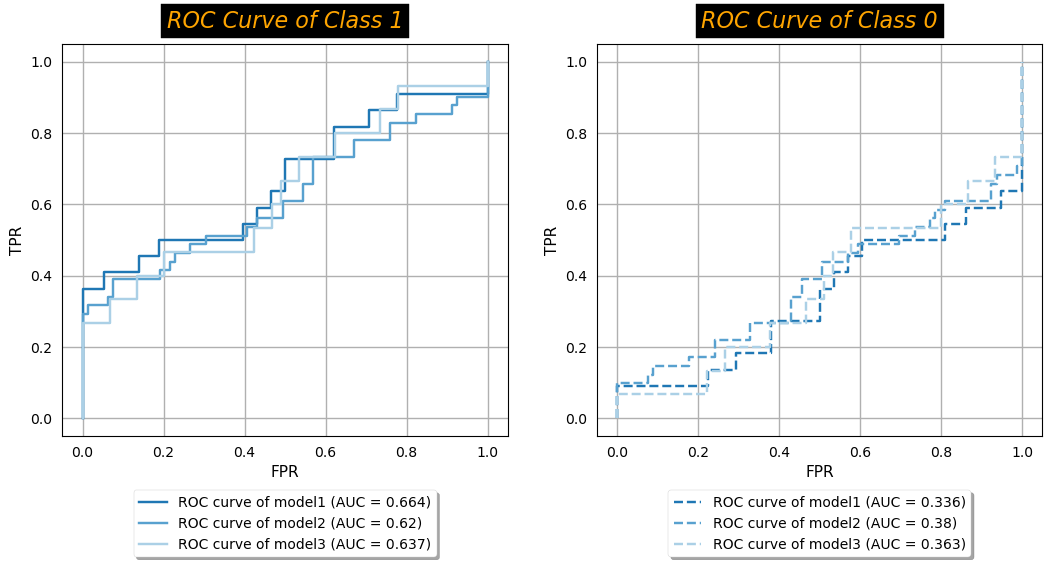

-------------------- Confusion Matrix --------------------
[[41  4]
 [10  5]]


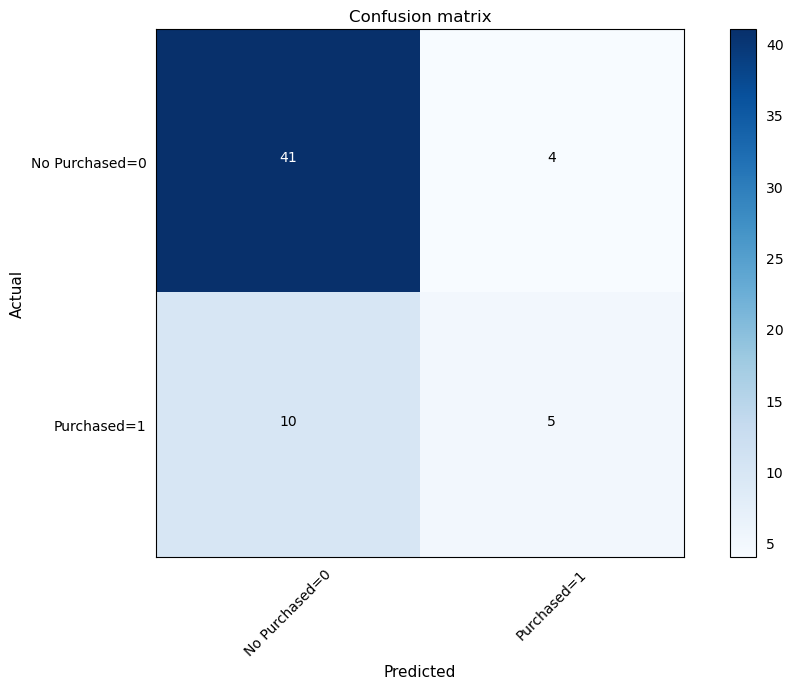

-------------------- Classification Report --------------------
                precision    recall  f1-score   support

No Purchased=0       0.80      0.91      0.85        45
   Purchased=1       0.56      0.33      0.42        15

      accuracy                           0.77        60
     macro avg       0.68      0.62      0.64        60
  weighted avg       0.74      0.77      0.74        60
 

Jaccard Score: 0.2631578947368421 



In [37]:
# test test_size= 0.15
clf3, acc_test3, acc_train3 = modeling(x, y, 0.15, ['No Purchased=0', 'Purchased=1'])

test_size = 0.15 did not improve the performance of the model.

-------------------- Shape --------------------
x_train: (360, 3)
y_train: (360, 1)
x_test: (40, 3)
y_test: (40, 1)


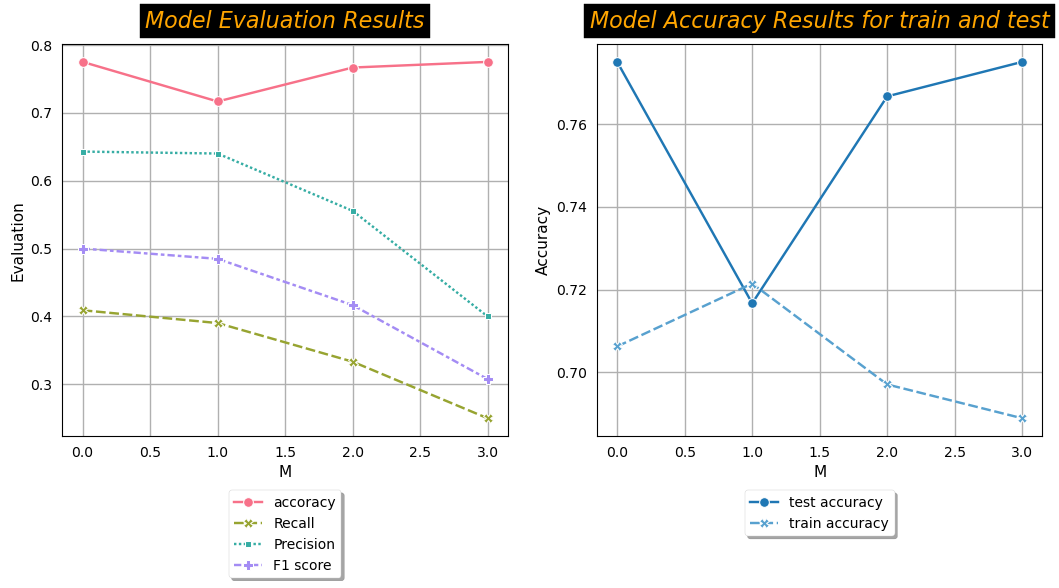

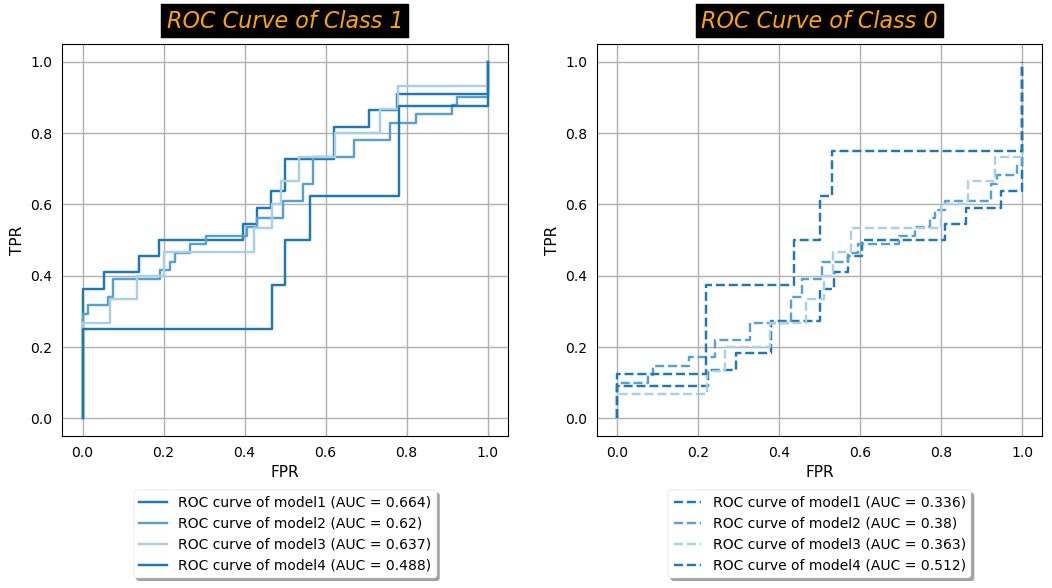

-------------------- Confusion Matrix --------------------
[[29  3]
 [ 6  2]]


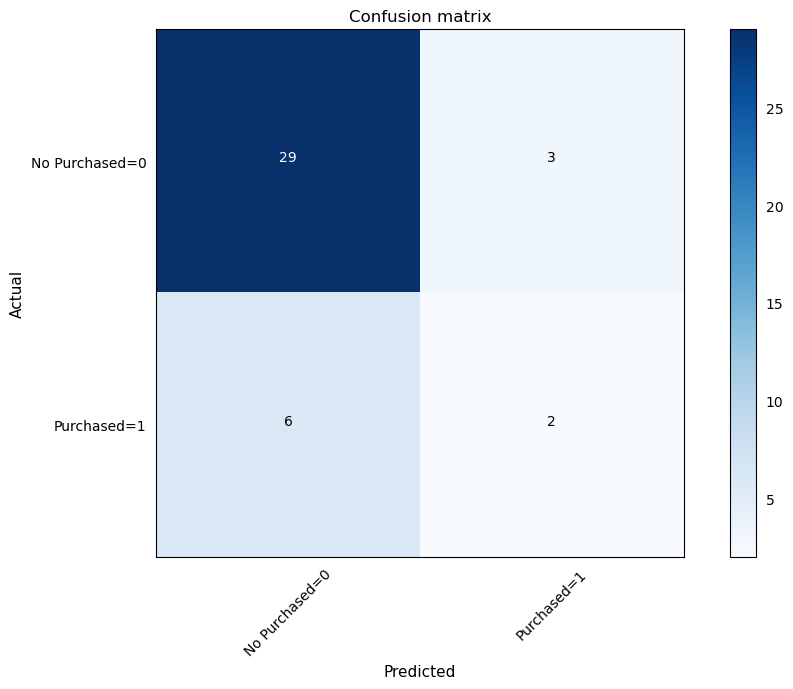

-------------------- Classification Report --------------------
                precision    recall  f1-score   support

No Purchased=0       0.83      0.91      0.87        32
   Purchased=1       0.40      0.25      0.31         8

      accuracy                           0.78        40
     macro avg       0.61      0.58      0.59        40
  weighted avg       0.74      0.78      0.75        40
 

Jaccard Score: 0.18181818181818182 



In [38]:
# test test_size= 0.1
clf3, acc_test3, acc_train3 = modeling(x, y, 0.1, ['No Purchased=0', 'Purchased=1'])

test_size = 0.1 did not improve the performance of the model.
So we delete 3 last results because they did not improve the performance of the model.

In [39]:
# delete 3 last results
del FPR1[1:]
del TPR1[1:]
del FPR0[1:]
del TPR0[1:]
del ACC_test[1:]
del ACC_train[1:]
del Recall[1:]
del Precision[1:]
del F1[1:]

Ok. So test_size=0.2 is better than other and edit this hyperparameter is not change much the performance of model.
Now we try to improve model by Cross Validation with `Perform_cross_val` function.

In [40]:
Perform_cross_val(clf1, 10, x, y, scoring='accuracy')

-------------------- CV for k=10, scoring=accuracy --------------------
CV mean: 0.6399999999999999
CV results: [0.925 0.825 0.8   0.7   0.85  0.4   0.5   0.55  0.6   0.25 ]



Folds 6 and 10 are more different from the average than other folds. Therefore, maybe by removing them, the model will be better:

In [41]:
# first find index of datapoint in fold 1 and 3 by following func:
find_fold_index(10, x)

fold 1: [0,39]
--------------------
fold 2: [40,79]
--------------------
fold 3: [80,119]
--------------------
fold 4: [120,159]
--------------------
fold 5: [160,199]
--------------------
fold 6: [200,239]
--------------------
fold 7: [240,279]
--------------------
fold 8: [280,319]
--------------------
fold 9: [320,359]
--------------------
fold 10: [360,399]
--------------------


Now we delete index `[200-239] , [360-399]`

In [42]:
# delete above index from df2
df3 = df2.drop(df2.index[np.r_[200:239+1, 360:399+1]], axis=0)
print(f'df2:{df2.shape}')
print(f'df3:{df3.shape}')

df2:(400, 4)
df3:(320, 4)


In [43]:
# define new x and y
x2 = np.asanyarray(df3.drop('Purchased', axis=1))
y2 = df3.Purchased.values.reshape(-1,1)

-------------------- Shape --------------------
x_train: (256, 3)
y_train: (256, 1)
x_test: (64, 3)
y_test: (64, 1)


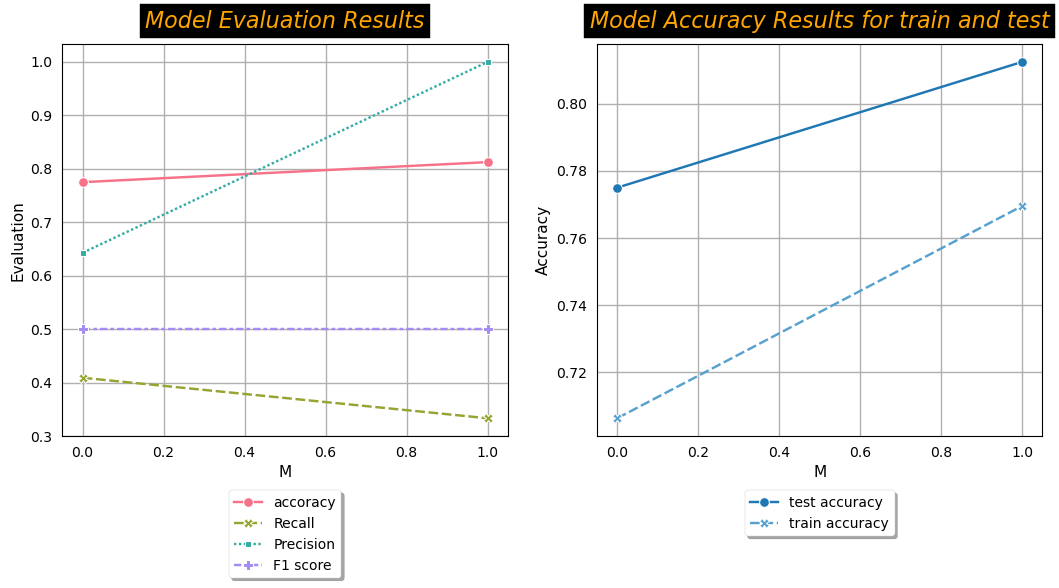

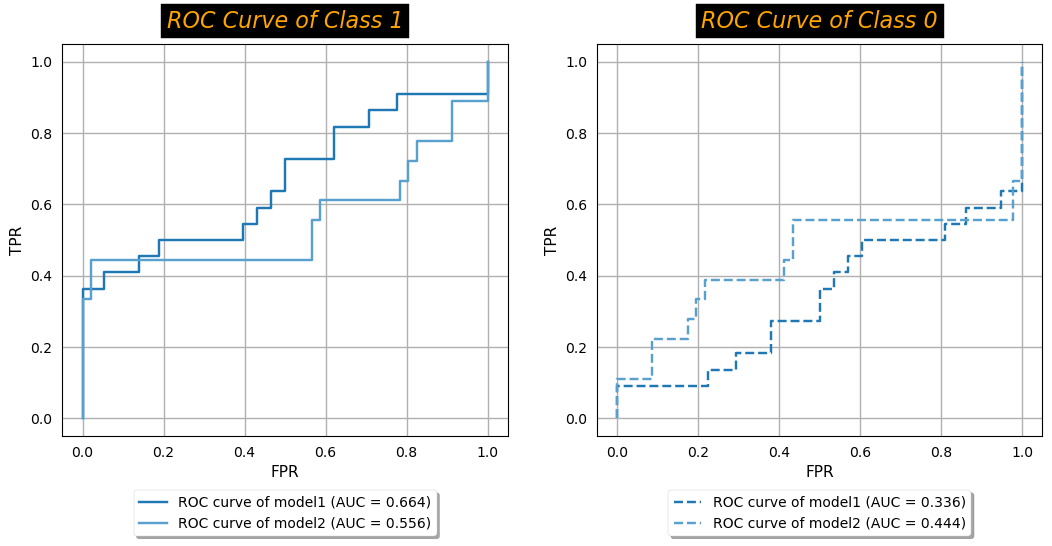

-------------------- Confusion Matrix --------------------
[[46  0]
 [12  6]]


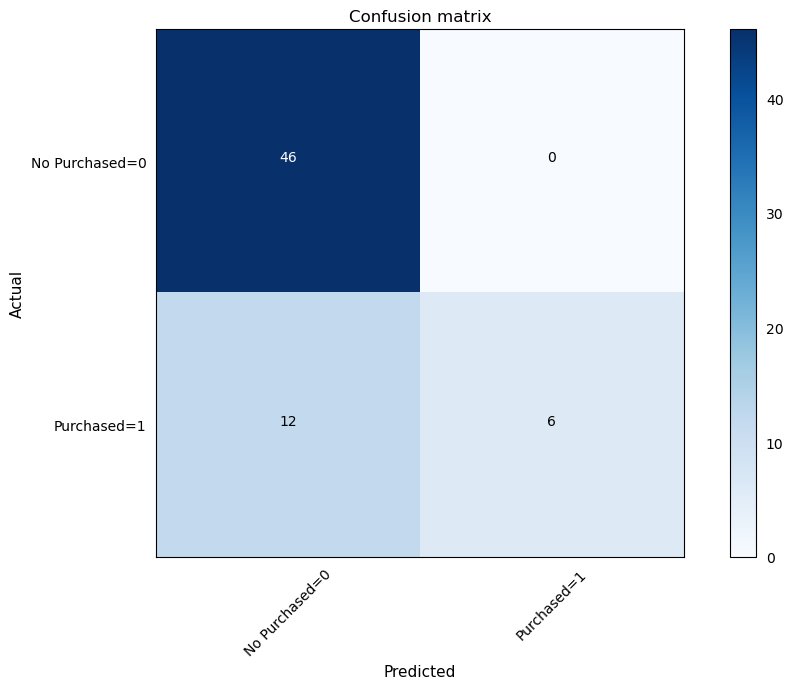

-------------------- Classification Report --------------------
                precision    recall  f1-score   support

No Purchased=0       0.79      1.00      0.88        46
   Purchased=1       1.00      0.33      0.50        18

      accuracy                           0.81        64
     macro avg       0.90      0.67      0.69        64
  weighted avg       0.85      0.81      0.78        64
 

Jaccard Score: 0.3333333333333333 



In [44]:
clf2, acc_test2, acc_train2 = modeling(x2, y2, 0.2, classes=['No Purchased=0', 'Purchased=1'])

Now the performance of the model has improved and reached an accuracy of 0.81. As shown in the confusion matrix and the classification report, due to the lack of data in class 1, the accuracy of this class is low, and the 12 people who decided to purchase were wrongly predicted as class zero. However, the accuracy achieved is good.

In [45]:
clf2.predict(x2)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,

In the figure drawn above, it is very clear that at the bottom of the cube where all the data are correctly predicted and all are red, but at the top of the cube where all the circles should be green, red circles are also seen, which indicates the wrong prediction.

Predicting Sample Data

In [46]:
# fit final model on all of data (train + test)
final_model = MultinomialNB()
final_model.fit(x2, y2)

# new sample data
new_sample = pd.DataFrame({'Gender': [1], 'Age': [18], 'EstimatedSalary': [70000]})
print(f"Gender: {new_sample['Gender'].values[0]}\n"
      f"Age: {new_sample['Age'].values[0]}\n"
      f"EstimatedSalary: {new_sample['EstimatedSalary'].values[0]}")

# Satandardize new_sample by use scaler
new_sample['EstimatedSalary'] = scaler.transform(new_sample[['EstimatedSalary']])
ns = np.asanyarray(new_sample)

# predict new sample data
result = final_model.predict(ns)
print('='*38)
print(f"class {result}")


Gender: 1
Age: 18
EstimatedSalary: 70000
class [0]


**SUPPORT VECTOR MACHINE**

-------------------- Shape --------------------
x_train: (320, 3)
y_train: (320, 1)
x_test: (80, 3)
y_test: (80, 1)


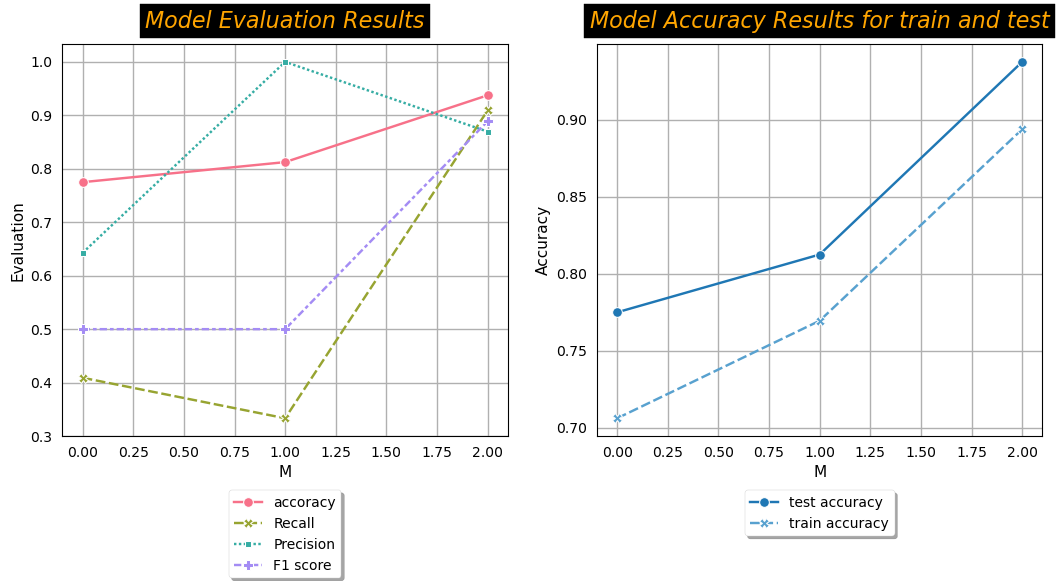

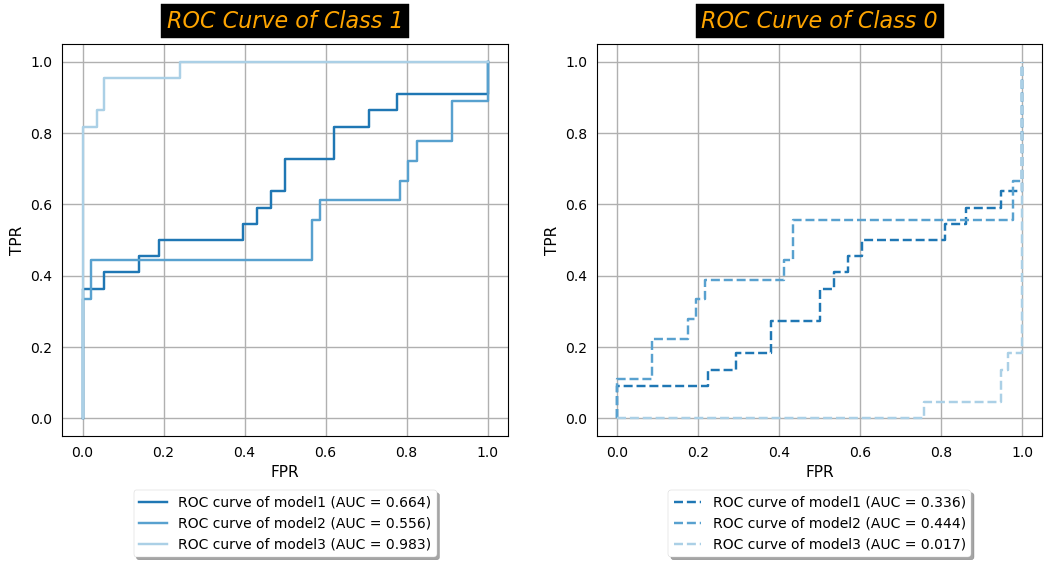

-------------------- Confusion Matrix --------------------
[[55  3]
 [ 2 20]]


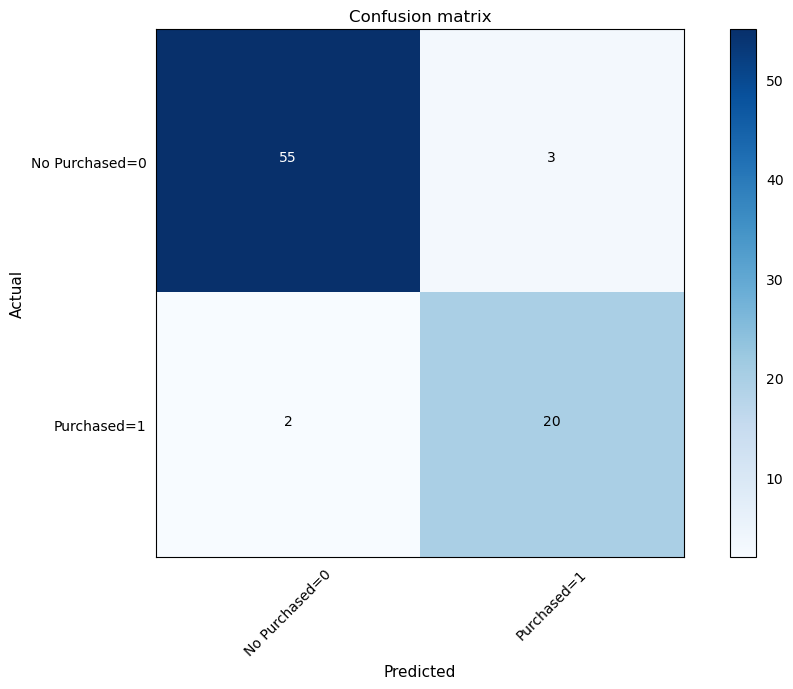

-------------------- Classification Report --------------------
                precision    recall  f1-score   support

No Purchased=0       0.96      0.95      0.96        58
   Purchased=1       0.87      0.91      0.89        22

      accuracy                           0.94        80
     macro avg       0.92      0.93      0.92        80
  weighted avg       0.94      0.94      0.94        80
 

Jaccard Score: 0.8 



In [47]:
# Import additional required libraries
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Update the modeling function to handle different models
def modeling(model, x, y, test_size, classes, is_add=1):
    """
    Generic modeling function that supports multiple classifiers.
    model: Classifier model (e.g., MultinomialNB, SVC, DecisionTreeClassifier).
    """

    # Split data into train and test sets
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=0)
    print(20 * '-', 'Shape', 20 * '-')
    print(f"x_train: {x_train.shape}")
    print(f"y_train: {y_train.shape}")
    print(f"x_test: {x_test.shape}")
    print(f"y_test: {y_test.shape}")

    # Fit the model
    model.fit(x_train, y_train.ravel())

    # Predictions and probabilities
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)
    if hasattr(model, 'predict_proba'):
        y_proba_test = model.predict_proba(x_test)
        y_proba_train = model.predict_proba(x_train)
    else:
        # For models like SVM without `predict_proba`, use decision function
        y_proba_test = model.decision_function(x_test)
        y_proba_train = model.decision_function(x_train)

    # Confusion matrix and metrics
    cm = metrics.confusion_matrix(y_test, y_pred_test)
    fpr1, tpr1, _ = metrics.roc_curve(y_test, y_proba_test if len(y_proba_test.shape) == 1 else y_proba_test[:, 1])
    fpr0, tpr0, _ = metrics.roc_curve(y_test, y_proba_test if len(y_proba_test.shape) == 1 else y_proba_test[:, 0])
    acc_test = metrics.accuracy_score(y_test, y_pred_test)
    acc_train = metrics.accuracy_score(y_train, y_pred_train)
    rec = metrics.recall_score(y_test, y_pred_test)
    pre = metrics.precision_score(y_test, y_pred_test)
    f1 = metrics.f1_score(y_test, y_pred_test)

    # Append results
    if is_add == 1:
        FPR0.append(fpr0)
        TPR0.append(tpr0)
        FPR1.append(fpr1)
        TPR1.append(tpr1)
        ACC_test.append(acc_test)
        ACC_train.append(acc_train)
        Recall.append(rec)
        Precision.append(pre)
        F1.append(f1)

    # Plot results
    plot_results(FPR0, TPR0, FPR1, TPR1, ACC_test, ACC_train, Recall, Precision, F1)

    # Evaluation model
    print('-' * 20, 'Confusion Matrix', '-' * 20)
    print(cm)
    plot_confusion_matrix2(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues)
    print('-' * 20, 'Classification Report', '-' * 20)
    print(metrics.classification_report(y_test, y_pred_test, target_names=classes), '\n')
    print(f"Jaccard Score: {metrics.jaccard_score(y_test, y_pred_test)}", '\n')

    return model, acc_test, acc_train


# Support Vector Machine Model
svm_model = SVC(probability=True, kernel='rbf', random_state=0)
clf_svm, acc_test_svm, acc_train_svm = modeling(svm_model, x, y, 0.2, ['No Purchased=0', 'Purchased=1'])



The accuracy of the model is 94% which is pretty good.


Predicting sample data


In [48]:
# fit final model on all of data (train + test)
final_model = SVC()
final_model.fit(x2, y2)

# new sample data
new_sample = pd.DataFrame({'Gender': [1], 'Age': [18], 'EstimatedSalary': [70000]})
print(f"Gender: {new_sample['Gender'].values[0]}\n"
      f"Age: {new_sample['Age'].values[0]}\n"
      f"EstimatedSalary: {new_sample['EstimatedSalary'].values[0]}")

# Satandardize new_sample by use scaler
new_sample['EstimatedSalary'] = scaler.transform(new_sample[['EstimatedSalary']])
ns = np.asanyarray(new_sample)

# predict new sample data
result = final_model.predict(ns)
print('='*38)
print(f"class {result}")

Gender: 1
Age: 18
EstimatedSalary: 70000
class [0]


**DECISION TREE CLASSIFIER**

-------------------- Shape --------------------
x_train: (320, 3)
y_train: (320, 1)
x_test: (80, 3)
y_test: (80, 1)


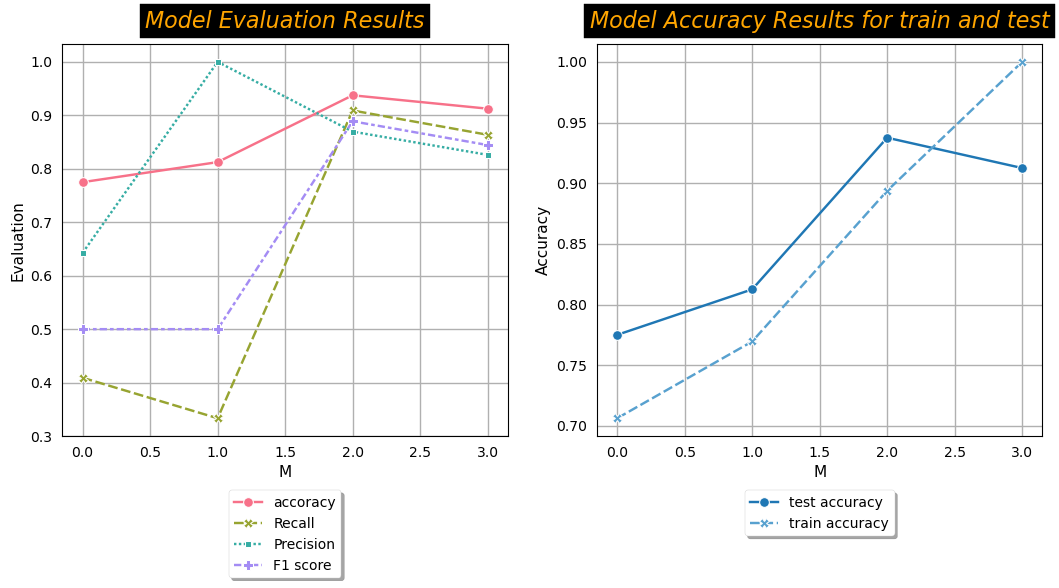

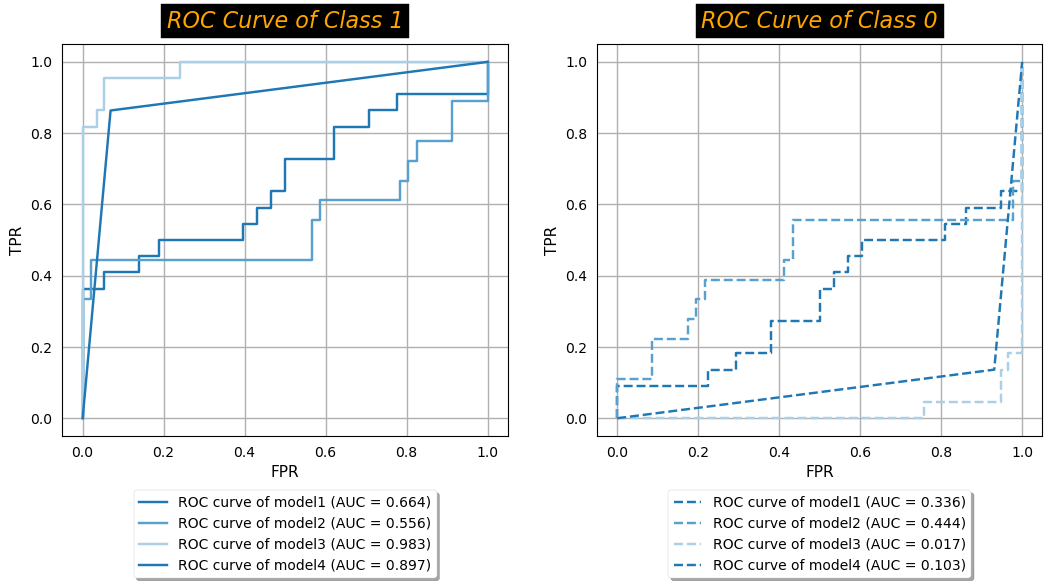

-------------------- Confusion Matrix --------------------
[[54  4]
 [ 3 19]]


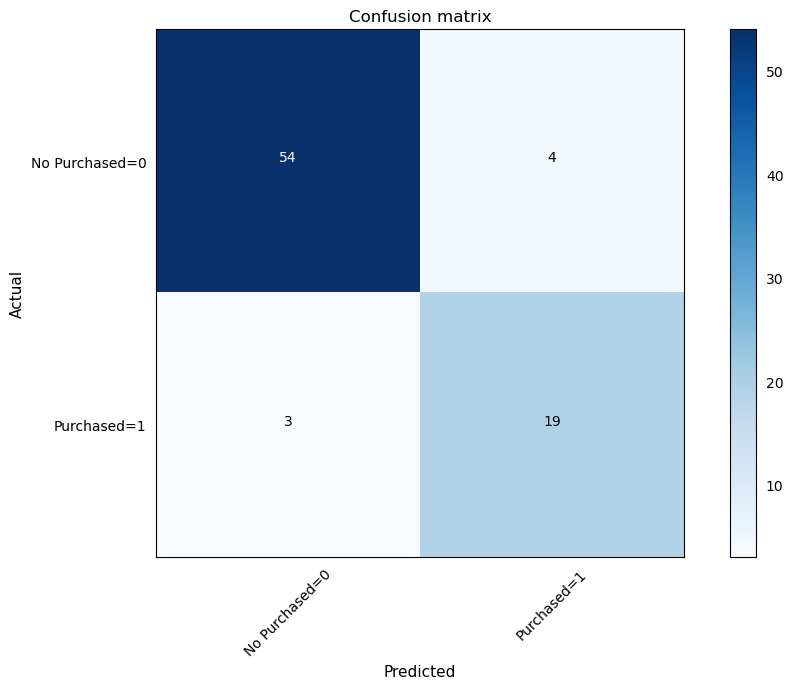

-------------------- Classification Report --------------------
                precision    recall  f1-score   support

No Purchased=0       0.95      0.93      0.94        58
   Purchased=1       0.83      0.86      0.84        22

      accuracy                           0.91        80
     macro avg       0.89      0.90      0.89        80
  weighted avg       0.91      0.91      0.91        80
 

Jaccard Score: 0.7307692307692307 



In [49]:
# Import additional required libraries
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Update the modeling function to handle different models
def modeling(model, x, y, test_size, classes, is_add=1):
    """
    Generic modeling function that supports multiple classifiers.
    model: Classifier model (e.g., MultinomialNB, SVC, DecisionTreeClassifier).
    """

    # Split data into train and test sets
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=0)
    print(20 * '-', 'Shape', 20 * '-')
    print(f"x_train: {x_train.shape}")
    print(f"y_train: {y_train.shape}")
    print(f"x_test: {x_test.shape}")
    print(f"y_test: {y_test.shape}")

    # Fit the model
    model.fit(x_train, y_train.ravel())

    # Predictions and probabilities
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)
    if hasattr(model, 'predict_proba'):
        y_proba_test = model.predict_proba(x_test)
        y_proba_train = model.predict_proba(x_train)
    else:
        # For models like SVM without `predict_proba`, use decision function
        y_proba_test = model.decision_function(x_test)
        y_proba_train = model.decision_function(x_train)

    # Confusion matrix and metrics
    cm = metrics.confusion_matrix(y_test, y_pred_test)
    fpr1, tpr1, _ = metrics.roc_curve(y_test, y_proba_test if len(y_proba_test.shape) == 1 else y_proba_test[:, 1])
    fpr0, tpr0, _ = metrics.roc_curve(y_test, y_proba_test if len(y_proba_test.shape) == 1 else y_proba_test[:, 0])
    acc_test = metrics.accuracy_score(y_test, y_pred_test)
    acc_train = metrics.accuracy_score(y_train, y_pred_train)
    rec = metrics.recall_score(y_test, y_pred_test)
    pre = metrics.precision_score(y_test, y_pred_test)
    f1 = metrics.f1_score(y_test, y_pred_test)

    # Append results
    if is_add == 1:
        FPR0.append(fpr0)
        TPR0.append(tpr0)
        FPR1.append(fpr1)
        TPR1.append(tpr1)
        ACC_test.append(acc_test)
        ACC_train.append(acc_train)
        Recall.append(rec)
        Precision.append(pre)
        F1.append(f1)

    # Plot results
    plot_results(FPR0, TPR0, FPR1, TPR1, ACC_test, ACC_train, Recall, Precision, F1)

    # Evaluation model
    print('-' * 20, 'Confusion Matrix', '-' * 20)
    print(cm)
    plot_confusion_matrix2(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues)
    print('-' * 20, 'Classification Report', '-' * 20)
    print(metrics.classification_report(y_test, y_pred_test, target_names=classes), '\n')
    print(f"Jaccard Score: {metrics.jaccard_score(y_test, y_pred_test)}", '\n')

    return model, acc_test, acc_train


# Decision Tree Model
dt_model = DecisionTreeClassifier(random_state=0)
clf_dt, acc_test_dt, acc_train_dt = modeling(dt_model, x, y, 0.2, ['No Purchased=0', 'Purchased=1'])




Accuracy in this is 90%, which is pretty good as well

Predicting sample data

In [50]:
# fit final model on all of data (train + test)
final_model = DecisionTreeClassifier()
final_model.fit(x2, y2)

# new sample data
new_sample = pd.DataFrame({'Gender': [1], 'Age': [18], 'EstimatedSalary': [70000]})
print(f"Gender: {new_sample['Gender'].values[0]}\n"
      f"Age: {new_sample['Age'].values[0]}\n"
      f"EstimatedSalary: {new_sample['EstimatedSalary'].values[0]}")

# Satandardize new_sample by use scaler
new_sample['EstimatedSalary'] = scaler.transform(new_sample[['EstimatedSalary']])
ns = np.asanyarray(new_sample)

# predict new sample data
result = final_model.predict(ns)
print('='*38)
print(f"class {result}")

Gender: 1
Age: 18
EstimatedSalary: 70000
class [0]


**Neural Network**

Iteration 1, loss = 0.60862770
Iteration 2, loss = 0.54721756
Iteration 3, loss = 0.49207990
Iteration 4, loss = 0.44710679
Iteration 5, loss = 0.40823828
Iteration 6, loss = 0.37450208
Iteration 7, loss = 0.34568691
Iteration 8, loss = 0.32083878
Iteration 9, loss = 0.30091637
Iteration 10, loss = 0.28431205
Iteration 11, loss = 0.26965827
Iteration 12, loss = 0.25716561
Iteration 13, loss = 0.24777947
Iteration 14, loss = 0.23820700
Iteration 15, loss = 0.23215148
Iteration 16, loss = 0.22550696
Iteration 17, loss = 0.21992336
Iteration 18, loss = 0.21595620
Iteration 19, loss = 0.21217493
Iteration 20, loss = 0.20955004
Iteration 21, loss = 0.20716902
Iteration 22, loss = 0.20514395
Iteration 23, loss = 0.20342272
Iteration 24, loss = 0.20176634
Iteration 25, loss = 0.20045005
Iteration 26, loss = 0.19884082
Iteration 27, loss = 0.19800914
Iteration 28, loss = 0.19617250
Iteration 29, loss = 0.19536676
Iteration 30, loss = 0.19452685
Iteration 31, loss = 0.19438380
Iteration 32, los

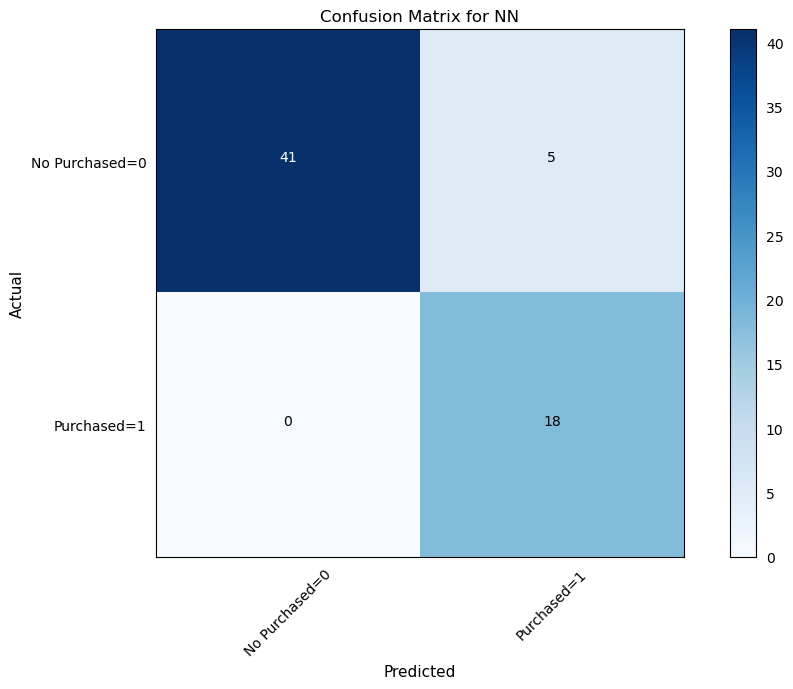

-------------------- Classification Report for NN Model --------------------
                precision    recall  f1-score   support

No Purchased=0       1.00      0.89      0.94        46
   Purchased=1       0.78      1.00      0.88        18

      accuracy                           0.92        64
     macro avg       0.89      0.95      0.91        64
  weighted avg       0.94      0.92      0.92        64
 



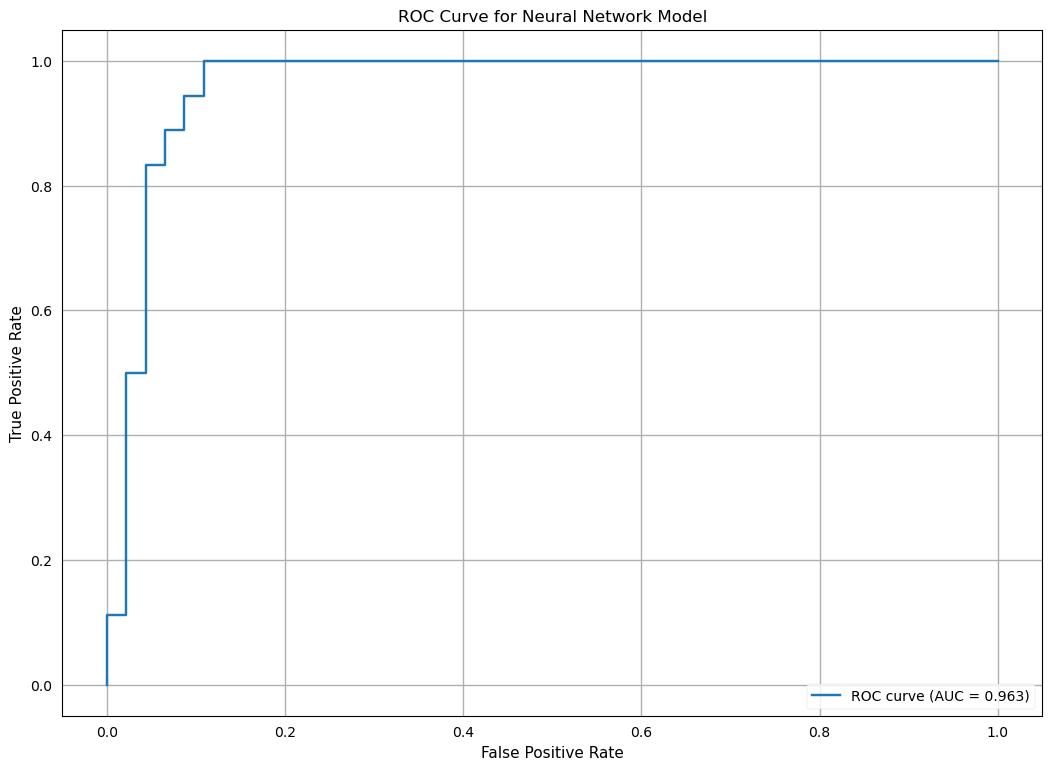

In [51]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# Scale
nn_scaler = StandardScaler()
x_scaled = nn_scaler.fit_transform(x2)

# Split
x_train_nn, x_test_nn, y_train_nn, y_test_nn = train_test_split(
    x_scaled, y2.ravel(), test_size=0.2, random_state=0
)

# Build + train (equivalent to 2 hidden layers of 64 and 32 neurons)
nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=50,
    batch_size=32,
    random_state=0,
    verbose=True
)
nn_model.fit(x_train_nn, y_train_nn)

# Evaluate
print(f"Training Accuracy: {nn_model.score(x_train_nn, y_train_nn):.4f}")
print(f"Test Accuracy:     {nn_model.score(x_test_nn, y_test_nn):.4f}")

# Predictions
y_pred_nn = nn_model.predict(x_test_nn)

# Confusion Matrix
cm_nn = metrics.confusion_matrix(y_test_nn, y_pred_nn)
plot_confusion_matrix2(cm_nn, ['No Purchased=0', 'Purchased=1'],
                       title='Confusion Matrix for NN', cmap=plt.cm.Blues)

# Classification Report
print('-'*20, 'Classification Report for NN Model', '-'*20)
print(metrics.classification_report(y_test_nn, y_pred_nn,
      target_names=['No Purchased=0', 'Purchased=1']), '\n')

# ROC Curve
y_proba_nn = nn_model.predict_proba(x_test_nn)[:, 1]
fpr_nn, tpr_nn, _ = metrics.roc_curve(y_test_nn, y_proba_nn)
plt.figure(figsize=(10, 7))
plt.plot(fpr_nn, tpr_nn, label=f'ROC curve (AUC = {round(metrics.auc(fpr_nn, tpr_nn), 3)})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Neural Network Model')
plt.legend(loc='lower right')
plt.show()